In [13]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

In [14]:
# Uploading the dataset
df = pd.read_csv('student_performance.csv')

In [15]:
# Inspect the data
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [16]:
# Deleting unnecessary information
df = df.drop('student_id' , axis = 1)

In [17]:
# Turning string inputs to numericals
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['parent_education'] = le.fit_transform(df['parent_education'])
df['internet_access'] = le.fit_transform(df['internet_access'])
df['extracurricular'] = le.fit_transform(df['extracurricular'])
df['passed'] = le.fit_transform(df['passed'])

In [18]:
# Inspecting the data after changes
df.head()

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,1,15,25,63.8,0,1,1,41,67,1
1,0,15,2,54.7,0,1,1,83,28,0
2,0,19,10,90.5,1,1,0,73,49,0
3,1,16,26,66.8,1,0,1,75,70,1
4,0,15,25,73.0,1,0,1,67,77,1


<Axes: >

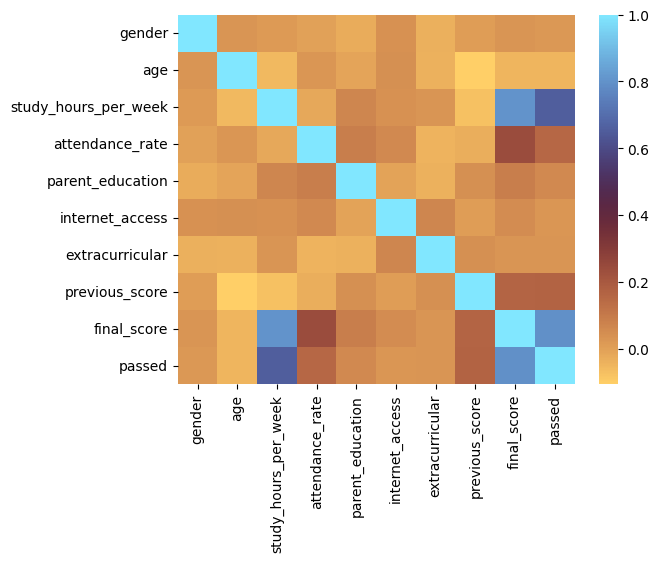

In [19]:
# Understanding the relevance of columns
sns.heatmap(df.corr() , annot = False , cmap = 'managua')

In [20]:
# Preparing data
X = df.drop('passed' , axis = 1)
y = df['passed']

In [21]:
# Splitting data
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2)

In [22]:
# Training data
svm = SVC(C = 1.0 , kernel = 'rbf')
svm.fit(X_train , y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
# Predicting
svm_pred = svm.predict(X_test)

In [24]:
# Model accuracy
accuracy_score(y_test , svm_pred)*100

96.0